In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install trackio -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.0/875.0 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.4/325.4 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.8/444.8 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 66.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [3]:
import trackio

In [4]:
# Huggingface Access Adding token to environment variable

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

import os 
os.environ['HF_TOKEN']  = user_secrets.get_secret("dlgenai_hf_access_token")

# Essential imports for deep learning and visualization

In [5]:
# Essential imports for deep learning and visualization
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import os
from torch.utils.data import DataLoader, WeightedRandomSampler


# GPU availibility and set Random Seeds

In [6]:
# Set random seeds for reproducibility
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("   Running on CPU")

print("\n✅ Environment setup complete!")

🚀 Using device: cuda
   GPU: Tesla T4
   Memory: 14.7 GB

✅ Environment setup complete!


# Visualize Image 

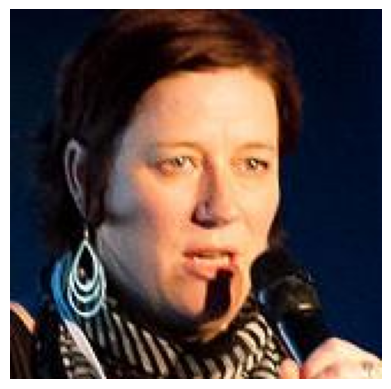

Image size: (162, 161)
Image mode: RGB


In [7]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = '/kaggle/input/sep-25-dl-gen-ai-nppe-1/face_dataset/train/00005.jpg'

img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()
print("Image size:", img.size)  # (width, height)
print("Image mode:", img.mode)  #  like RGB 

# Data Loading & Preprocessing

In [8]:
# --------------------------
# 1) Paths and CSVs
# --------------------------
train_path = "/kaggle/input/sep-25-dl-gen-ai-nppe-1/face_dataset/train"
test_path  = "/kaggle/input/sep-25-dl-gen-ai-nppe-1/face_dataset/test"
sample_sub = "/kaggle/input/sep-25-dl-gen-ai-nppe-1/face_dataset/sample_submission.csv"

train_df = pd.read_csv("/kaggle/input/sep-25-dl-gen-ai-nppe-1/face_dataset/train.csv")
test_df  = pd.read_csv("/kaggle/input/sep-25-dl-gen-ai-nppe-1/face_dataset/test.csv")

print("Train rows:", len(train_df))
print("Test  rows:", len(test_df))
train_df.head(), test_df.head()


Train rows: 34708
Test  rows: 8677


(   id        full_path  gender  age
 0   0  train/00000.jpg       1   66
 1   1  train/00001.jpg       1   53
 2   2  train/00002.jpg       1   20
 3   3  train/00003.jpg       1   32
 4   4  train/00004.jpg       1   21,
    id       full_path
 0   0  test/00000.jpg
 1   1  test/00001.jpg
 2   2  test/00002.jpg
 3   3  test/00003.jpg
 4   4  test/00004.jpg)

In [9]:
(train_df.shape[0]/100)*10

3470.7999999999997

In [10]:
# --------------------------
# 2) Simple torchvision transforms (using your known size)
# --------------------------
IMG_SIZE = 174  # your image size

def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),   # ensures all are 174x174
            transforms.RandomHorizontalFlip(p=0.5),   # optional augmentation
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),   # same size for validation/test
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225]),
        ])


### Creating a Class that will do:

- Reads each row of your CSV file (like train.csv or test.csv)

- Finds the image file for that row

- Opens the image and transforms it (resize, normalize, etc.)

Returns:

- the image as a PyTorch tensor and either the labels (age, gender) or the id (for test data)

In [11]:
# --------------------------
# 1.5) Normalize full_path columns (fixes train/train issue)
# --------------------------
import os

train_df['full_path'] = train_df['full_path'].astype(str).apply(lambda p: os.path.basename(p))
test_df['full_path']  = test_df['full_path'].astype(str).apply(lambda p: os.path.basename(p))


In [12]:
# Fixed FaceDataset (drop-in replacement)
from PIL import Image
import os
import torch
import numpy as np
from torch.utils.data import Dataset

class FaceDataset(Dataset):
    """
    df: pandas DataFrame (must contain columns 'full_path', 'age', 'gender' or 'id' for test)
    images_dir: folder path that contains the image files (e.g. '/kaggle/input/.../train')
    train: bool -> controls get_transforms(train=...)
    is_test: bool -> if True returns (img, id)
    target: "age", "gender", or "both" -> controls returned label(s)
    """
    def __init__(self, df, images_dir, train=True, is_test=False, target="both"):
        # reset index so positional indexing .iloc[...] is safe
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = get_transforms(train=train)
        self.is_test = is_test
        assert target in ("age", "gender", "both")
        self.target = target

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # make idx a plain Python int (handles torch.Tensor, np.int64, etc.)
        if isinstance(idx, torch.Tensor):
            idx = idx.item()
        try:
            if isinstance(idx, (np.integer,)):
                idx = int(idx)
        except Exception:
            pass
        idx = int(idx)

        # positional row access
        row = self.df.iloc[idx]
        full_path = str(row.get("full_path", "")).strip()

        # ----- SAFER PATH RESOLUTION -----
        # 1) try images_dir / full_path (candidate)
        # 2) otherwise fall back to images_dir / basename(full_path)
        cand = os.path.join(self.images_dir, full_path)
        base = os.path.join(self.images_dir, os.path.basename(full_path))

        if os.path.exists(cand):
            img_path = cand
        elif os.path.exists(base):
            img_path = base
        else:
            # helpful error so you can see exactly what failed
            raise FileNotFoundError(
                f"Image not found. Tried:\n"
                f"  candidate: {cand}\n"
                f"  basename : {base}\n"
                f"Row full_path: {full_path}\nimages_dir: {self.images_dir}"
            )

        # load and transform
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        if self.is_test:
            sample_id = row.get("id", idx)
            return image, sample_id

        # return requested targets
        if self.target == "age":
            age = torch.tensor(row["age"], dtype=torch.float32)
            return image, age
        elif self.target == "gender":
            gender = torch.tensor(row["gender"], dtype=torch.long)
            return image, gender
        else:
            age = torch.tensor(row["age"], dtype=torch.float32)
            gender = torch.tensor(row["gender"], dtype=torch.long)
            return image, {"age": age, "gender": gender}


Loading using the above class

In [13]:
from sklearn.model_selection import train_test_split
# --------------------------
# 📊 Split train data into train + validation
# --------------------------
# Take 10% of the training data for validation
train_df_split, val_df = train_test_split(
    train_df,
    test_size=0.10,         # change to 0.05 if you want 5%
    random_state=42,        # keeps it consistent every run
    stratify=train_df["gender"]  # keeps gender ratio same in both sets
)

print(f"Train size: {len(train_df_split)}")
print(f"Validation size: {len(val_df)}")


# 3) Build datasets for each target
train_ds    = FaceDataset(train_df_split, images_dir=train_path, train=True,  is_test=False, target="both")
val_ds    = FaceDataset(val_df, images_dir=train_path, train=False, is_test=False, target="both")

# test dataset 
test_ds  = FaceDataset(test_df, images_dir=test_path, train=False, is_test=True, target="both")


Train size: 31237
Validation size: 3471


In [14]:
img, label = train_ds[0]
print(type(img), img.shape)
print(label)

<class 'torch.Tensor'> torch.Size([3, 174, 174])
{'age': tensor(54.), 'gender': tensor(1)}


# Build DataLoaders

In [15]:
import numpy as np
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

# 1) Compute sample weights from the training split (not full train_df)
g = train_df_split['gender'].values.astype(int)   # ensure ints 0/1

# 2) Inverse-frequency class weights -> per-sample weights
class_counts = np.bincount(g)                     # [count_class0, count_class1]
class_weights = 1.0 / class_counts                # inverse frequency per class
sample_weights = class_weights[g]                 # weight per sample (numpy array)

# 3) sampler requires sequence of floats (or torch tensor)
sample_weights = torch.as_tensor(sample_weights, dtype=torch.double)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# 4) Build DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = 2   # use 0 while debugging

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,          # balanced sampling
    num_workers=NUM_WORKERS,
    pin_memory=True           # set to False if not using CUDA
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)



# Model Building

# Model Built From Scratch

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    """
    3-conv CNN (your blocks) + two heads:
      - age_head: regression (scalar)
      - gender_head: classification (2 logits)
    Uses AdaptiveAvgPool so you don't need to hardcode feature sizes.
    """
    def __init__(self, in_channels=3, dropout=0.5):
        super(SimpleCNN, self).__init__()

        # --- Conv block 1 ---
        self.conv1 = nn.Conv2d(
            in_channels=3,         # RGB input
            out_channels=32,       # 32 filters
            kernel_size=3,         # 3×3 kernel
            stride=1,              # Default stride
            padding=1              # Keep spatial dimensions
        )
        self.relu1 = nn.ReLU()     # ReLU activation
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 2×2 max pooling

        # --- Conv block 2 ---
        self.conv2 = nn.Conv2d(
            in_channels=32,        # Input from previous layer
            out_channels=64,       # 64 filters
            kernel_size=3,         # 3×3 kernel
            stride=1,              # Default stride
            padding=1              # Keep spatial dimensions
        )
        self.relu2 = nn.ReLU()     # ReLU activation
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 2×2 max pooling

        # --- Conv block 3 ---
        self.conv3 = nn.Conv2d(
            in_channels=64,        # Input from previous layer
            out_channels=128,      # 128 filters
            kernel_size=3,         # 3×3 kernel
            stride=1,              # Default stride
            padding=1              # Keep spatial dimensions
        )
        self.relu3 = nn.ReLU()     # ReLU activation
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # 2×2 max pooling

        # --- Adaptive pooling to get fixed-size feature regardless of input HxW ---
        # This outputs (B, 128, 1, 1) which we flatten to (B, 128)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()

        # --- Shared FC (optional small bottleneck) ---
        self.fc_shared = nn.Linear(128, 128)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)

        # --- Heads ---
        # Age head -> single scalar (regression)
        self.age_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(64, 1)   # output a single number (age)
        )

        # Gender head -> 2 logits (classification)
        self.gender_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(64, 2)   # 2 logits for gender classes
        )

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        # global pooling -> flatten
        x = self.global_pool(x)  # (B,128,1,1)
        x = self.flatten(x)      # (B,128)

        # optional shared fc
        x = self.fc_shared(x)
        x = self.relu4(x)
        x = self.dropout(x)

        # heads
        age_out = self.age_head(x).view(-1)         # (B,) - regression scalar
        gender_logits = self.gender_head(x)         # (B,2) - raw logits

        return age_out, gender_logits


## Training Loop

| Part                       | Purpose                                                                                                                                                     |
| -------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`train_one_epoch`**      | Loops through the training data once — computes losses, performs backpropagation, and updates model weights.                                                |
| **`validate_one_epoch`**   | Evaluates model performance on validation data (no gradient updates).                                                                                       |
| **`train_model`**          | High-level loop that calls `train_one_epoch` and `validate_one_epoch` for multiple epochs, logs metrics, and saves the best model based on validation loss. |
| **`alpha`, `beta`**        | Control how much weight to give to each loss: `alpha` for age regression, `beta` for gender classification.                                                 |
| **Progress bars (`tqdm`)** | Show live updates of loss, age MAE, and gender accuracy for each batch.                                                                                     |
| **Plots**                  | Visualize how loss decreases and accuracy/MAE improves across epochs.                                                                                       |


In [17]:
# 📦 Import required libraries
# ---------------------------------------------------
import time
from tqdm.notebook import tqdm       # For progress bars
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# ---------------------------------------------------
# 1️⃣ PREPARE MODEL, LOSSES, OPTIMIZER
# ---------------------------------------------------

# Initialize our CNN (RGB images → in_channels=3)
model = SimpleCNN(in_channels=3, dropout=0.5).to(device)

# compute counts from training split
counts = train_df_split['gender'].value_counts().sort_index().values.astype(float)  # [count0, count1]
print("class counts:", counts)   # sanity

# inverse frequency (higher weight for minority class)
inv_freq = 1.0 / counts
# normalize optional
inv_norm = inv_freq / inv_freq.sum()

class_weights = torch.tensor(inv_norm, dtype=torch.float).to(device)
print("class weights (for [0,1]):", class_weights)

gender_loss_fn = nn.CrossEntropyLoss(weight=class_weights)

# age loss stays same (regression)
age_loss_fn = nn.L1Loss()

# Optimizer (Adam usually works well for CNNs)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Optional learning rate scheduler (can lower LR every few epochs)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Weight for combining two losses
alpha = 0.2   # Weight for age loss
beta = 1.0    # Weight for gender loss

# ---------------------------------------------------
# 2️⃣ TRAINING AND VALIDATION FUNCTIONS
# ---------------------------------------------------

def train_one_epoch(model, loader, optimizer, age_loss_fn, gender_loss_fn, device, alpha=1.0, beta=1.0):
    """
    Runs one full training epoch (forward + backward) on the training data.
    Returns average loss, MAE (for age), and accuracy (for gender).
    """
    model.train()   # put model in training mode (enables dropout, BN updates)

    # Track losses and metrics
    running = {"loss":0.0, "age_loss":0.0, "gender_loss":0.0, "age_mae":0.0, "gender_acc":0.0}
    n_samples = 0

    # tqdm gives a nice progress bar
    progress = tqdm(enumerate(loader), total=len(loader), desc="Train", leave=False)

    for i, (imgs, labels) in progress:
        # Move data to GPU/CPU device
        imgs = imgs.to(device)
        ages = labels["age"].to(device)
        genders = labels["gender"].to(device)

        # Reset optimizer gradients
        optimizer.zero_grad()

        # Forward pass → model returns two outputs
        age_preds, gender_logits = model(imgs)   # age_preds: (B,), gender_logits: (B,2)

        # Compute individual losses
        loss_age = age_loss_fn(age_preds, ages)
        loss_gender = gender_loss_fn(gender_logits, genders)

        # Combine both losses (weighted sum)
        loss = alpha * loss_age + beta * loss_gender

        # Backpropagation
        loss.backward()
        optimizer.step()

        # Batch size
        bs = imgs.size(0)
        n_samples += bs

        # Accumulate batch losses (to compute epoch average later)
        running["loss"] += loss.item() * bs
        running["age_loss"] += loss_age.item() * bs
        running["gender_loss"] += loss_gender.item() * bs

        # ---- Calculate extra metrics (MAE & accuracy) ----
        with torch.no_grad():
            # MAE for age
            age_mae = torch.abs(age_preds - ages).mean().item()

            # Accuracy for gender
            pred_gender = torch.argmax(gender_logits, dim=1)
            gender_acc = (pred_gender == genders).float().mean().item()

        # Accumulate metrics
        running["age_mae"] += age_mae * bs
        running["gender_acc"] += gender_acc * bs

        # ---- Update progress bar ----
        avg_loss = running["loss"] / n_samples
        avg_age_mae = running["age_mae"] / n_samples
        avg_gender_acc = 100.0 * (running["gender_acc"] / n_samples)
        progress.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "age_MAE": f"{avg_age_mae:.3f}",
            "gender_acc": f"{avg_gender_acc:.2f}%"
        })

    # Compute average metrics for the full epoch
    for k in running:
        running[k] /= n_samples
    running["gender_acc"] *= 100.0  # convert to percentage
    return running


@torch.no_grad()   # disables gradient tracking (faster, less memory)
def validate_one_epoch(model, loader, age_loss_fn, gender_loss_fn, device, alpha=1.0, beta=1.0):
    """
    Runs one full validation epoch (no gradient updates).
    Returns average loss, MAE (for age), and accuracy (for gender).
    """
    model.eval()  # set to evaluation mode (turns off dropout, etc.)

    running = {"loss":0.0, "age_loss":0.0, "gender_loss":0.0, "age_mae":0.0, "gender_acc":0.0}
    n_samples = 0

    progress = tqdm(enumerate(loader), total=len(loader), desc="Val", leave=False)

    for i, (imgs, labels) in progress:
        imgs = imgs.to(device)
        ages = labels["age"].to(device)
        genders = labels["gender"].to(device)

        # Forward pass only (no backward)
        age_preds, gender_logits = model(imgs)

        # Compute same losses as training
        loss_age = age_loss_fn(age_preds, ages)
        loss_gender = gender_loss_fn(gender_logits, genders)
        loss = alpha * loss_age + beta * loss_gender

        bs = imgs.size(0)
        n_samples += bs

        # Accumulate losses
        running["loss"] += loss.item() * bs
        running["age_loss"] += loss_age.item() * bs
        running["gender_loss"] += loss_gender.item() * bs

        # Metrics
        age_mae = torch.abs(age_preds - ages).mean().item()
        pred_gender = torch.argmax(gender_logits, dim=1)
        gender_acc = (pred_gender == genders).float().mean().item()

        running["age_mae"] += age_mae * bs
        running["gender_acc"] += gender_acc * bs

        # Update progress bar
        avg_loss = running["loss"] / n_samples
        avg_age_mae = running["age_mae"] / n_samples
        avg_gender_acc = 100.0 * (running["gender_acc"] / n_samples)
        progress.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "age_MAE": f"{avg_age_mae:.3f}",
            "gender_acc": f"{avg_gender_acc:.2f}%"
        })

    # Average over dataset
    for k in running:
        running[k] /= n_samples
    running["gender_acc"] *= 100.0
    return running
    

class counts: [ 7762. 23475.]
class weights (for [0,1]): tensor([0.7515, 0.2485], device='cuda:0')


In [18]:
import time
import torch
import trackio

def train_model_with_trackio(
    model,
    train_loader,
    val_loader,
    train_one_epoch,        
    validate_one_epoch,     
    optimizer,
    age_loss_fn,
    gender_loss_fn,
    device,
    num_epochs=10,
    alpha=1.0,
    beta=1.0,
    save_path="best_multitask.pth",
    # TrackIO config
    trackio_project="25-t3-nppe1",
    trackio_space="mohammedshad/dlgenai-nppe",
    model_group="simplecnn",
    run_name=None
):
    """
    Trains the model for multiple epochs, logs metrics to TrackIO,
    and saves the best model checkpoint (based on validation loss).
    """

    # ✅ Initialize TrackIO run
    trackio.init(
        project=trackio_project,
        space_id=trackio_space,
        group=model_group,
        name=run_name,
        config={
            "model": "SimpleCNN",
            "epochs": num_epochs,
            "alpha": alpha,
            "beta": beta,
            "lr": optimizer.param_groups[0]["lr"]
        }
    )

    history = {
        "train_loss": [], "val_loss": [],
        "train_age_mae": [], "val_age_mae": [],
        "train_gender_acc": [], "val_gender_acc": []
    }

    best_val_loss = float("inf")
    start_time = time.time()

    try:
        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch + 1}/{num_epochs}")

            # ---- Train and Validate ----
            train_stats = train_one_epoch(model, train_loader, optimizer, age_loss_fn, gender_loss_fn, device, alpha, beta)
            val_stats = validate_one_epoch(model, val_loader, age_loss_fn, gender_loss_fn, device, alpha, beta)

            # ---- Print summary ----
            print(f" Train -> loss: {train_stats['loss']:.4f}, age_MAE: {train_stats['age_mae']:.3f}, gender_acc: {train_stats['gender_acc']:.2f}%")
            print(f" Val   -> loss: {val_stats['loss']:.4f}, age_MAE: {val_stats['age_mae']:.3f}, gender_acc: {val_stats['gender_acc']:.2f}%")

            # ---- Save metrics ----
            for key in history.keys():
                if "train" in key:
                    history[key].append(train_stats[key.split('_', 1)[1]])
                else:
                    history[key].append(val_stats[key.split('_', 1)[1]])

            # ---- Save best model ----
            if val_stats["loss"] < best_val_loss:
                best_val_loss = val_stats["loss"]
                torch.save(model.state_dict(), save_path)
                print(" ✅ Saved best model so far.")

            # ---- Log metrics to TrackIO ----
            trackio.log({
                "epoch": epoch + 1,
                "train/loss": train_stats["loss"],
                "train/age_mae": train_stats["age_mae"],
                "train/gender_acc": train_stats["gender_acc"],
                "val/loss": val_stats["loss"],
                "val/age_mae": val_stats["age_mae"],
                "val/gender_acc": val_stats["gender_acc"],
                "lr": optimizer.param_groups[0]["lr"]
            }, step=epoch + 1)

    finally:
        # ✅ Always finish TrackIO run
        trackio.finish()
        elapsed = time.time() - start_time
        print(f"\nTraining finished in {elapsed:.1f}s. TrackIO run finished.")

    return history


In [19]:
# # quick check on a val batch
# model.eval()
# imgs, labels = next(iter(val_loader))
# imgs = imgs.to(device)
# true_genders = labels["gender"].to(device)

# with torch.no_grad():
#     _, logits = model(imgs)
#     preds = torch.argmax(logits, dim=1)

# print("True counts (batch):", torch.bincount(true_genders).cpu().numpy())
# print("Pred counts (batch):", torch.bincount(preds).cpu().numpy())
# print("First 20 true:", true_genders[:20].cpu().numpy())
# print("First 20 pred:", preds[:20].cpu().numpy())


In [20]:
# history = train_model_with_trackio(
#     model=model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     train_one_epoch=train_one_epoch,
#     validate_one_epoch=validate_one_epoch,
#     optimizer=optimizer,
#     age_loss_fn=age_loss_fn,
#     gender_loss_fn=gender_loss_fn,
#     device=device,
#     num_epochs=8,
#     alpha=1.0,
#     beta=1.0,
#     save_path="simplecnn_best.pth",
#     trackio_project="25-t3-nppe1",
#     trackio_space="mohammedshad/dlgenai-nppe",  # set None if you don't want Trackio to manage/create a HF Space
#     model_group="simplecnn",
#     run_name="simplecnn_lr1e-3"
# )


## Visualizing the Training metrics

### 💡 What it shows

- 📉 **Loss Curve:**  
  Shows how well your model minimizes the total **training** and **validation** loss over epochs.  
  _Lower values mean the model is learning effectively._

- 👶 **Age MAE (Mean Absolute Error):**  
  Plots the average difference between predicted and actual ages.  
  _Smaller values mean the predictions are closer to the real ages._

- 🚻 **Gender Accuracy:**  
  Displays how accurately the model classifies gender on both training and validation data.  
  _Higher percentages mean better classification performance._



In [21]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """Simple function to visualize training and validation metrics."""
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14, 5))

    # 🔹 Plot Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label='Train Loss', marker='o')
    plt.plot(epochs, history["val_loss"], label='Val Loss', marker='o')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 🔹 Plot Age MAE
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_age_mae"], label='Train Age MAE', marker='o')
    plt.plot(epochs, history["val_age_mae"], label='Val Age MAE', marker='o')
    plt.title('Age Mean Absolute Error')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)

    # 🔹 Plot Gender Accuracy
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["train_gender_acc"], label='Train Gender Acc', marker='o')
    plt.plot(epochs, history["val_gender_acc"], label='Val Gender Acc', marker='o')
    plt.title('Gender Accuracy (%)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# # ✅ Call after training:
# plot_training_history(history)


## Saving the Model to Kaggle

In [22]:
# # 1️⃣ Save best model checkpoint
# torch.save(model.state_dict(), "simplecnn_best.pth")
# print("✅ Model saved locally.")

# # 2️⃣ Prepare folder
# from pathlib import Path   # ✅ you need this line once

# # model_dir = Path("simplecnn_model")
# # model_dir.mkdir(exist_ok=True)
# # Path("simplecnn_best.pth").rename(model_dir / "simplecnn_best.pth")
# model_upload_path = '/kaggle/working'
# # 3️⃣ Upload to Kaggle Hub
# import kagglehub

# handle = "mohammedshad7013/face-age-gender/pytorch/simplecnn-v1"
# kagglehub.model_upload(
#     handle,
#     model_upload_path,
#     version_notes="Trained SimpleCNN multitask model (age + gender)"
# )


## Inference Model

## Retreving the Model from kaggle

In [23]:
import torch
# path to your uploaded model on Kaggle Models Hub
model_path = '/kaggle/input/face-age-gender/pytorch/simplecnn-v1/1/simplecnn_best.pth'

# initialize model (must match your training architecture)
model = SimpleCNN(in_channels=3).to(device)

# load trained weights
model.load_state_dict(torch.load(model_path, map_location=device))

# set to eval mode for inference
model.eval()

print("✅ Model loaded successfully and ready for inference!")

✅ Model loaded successfully and ready for inference!


In [24]:
sample_sub = pd.read_csv(sample_sub)
sample_sub

,id,gender,age
0,0,0,28
1,1,0,52
2,2,1,17
3,3,1,59
4,4,1,31
...,...,...,...
8672,8672,0,23
8673,8673,1,52
8674,8674,1,54
8675,8675,1,41


## Prediction

In [25]:

# # storage for predictions
# predictions = []

# with torch.no_grad():
#     for imgs, img_names in tqdm(test_loader, desc="Running inference"):
#         imgs = imgs.to(device)

#         # forward pass
#         age_preds, gender_logits = model(imgs)

#         # convert outputs to usable predictions
#         age_preds = age_preds.cpu().numpy()
#         gender_preds = torch.argmax(gender_logits, dim=1).cpu().numpy()  # 0 or 1

#         # store results
#         for name, age, gender in zip(img_names, age_preds, gender_preds):
#             predictions.append({
#                 "image": name,
#                 "predicted_age": round(float(age), 2),
#                 "predicted_gender": 1 if gender == 1 else 0
#             })

# # convert to dataframe
# pred_df = pd.DataFrame(predictions)

# pred_df

In [26]:
# sample_sub['gender'] = pred_df['predicted_gender']
# sample_sub['age'] = pred_df['predicted_age']
# sample_sub

## Saving as CSV

In [27]:
# sample_sub.to_csv('submission.csv',index_label='ImageId')

- my scratch model gave me a score of 0.460 in leaderboard 
- the one thing that i noticed in my model's prediction was that in the gender prediction part it always predicts men I mean all the values that's when I looked into the data and found class imbalance in gender then I implimented two techniques for the class imbalance still no use the validation is stuck

# Transfer Learning

## ResNet

In [28]:
# -------------------------
# ResNet heads-only training (one-cell quick experiment)
# -------------------------
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from pathlib import Path
import numpy as np
from torch.utils.data import DataLoader, WeightedRandomSampler

# 0) device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 1) ResNet multitask model (drop-in)
class ResNetMultitask(nn.Module):
    def __init__(self, backbone="resnet18", pretrained=True, dropout=0.5, in_channels=3):
        super().__init__()
        assert backbone in ("resnet18","resnet34","resnet50")
        if backbone == "resnet18":
            self.backbone = models.resnet18(pretrained=pretrained)
            feat_dim = 512
        elif backbone == "resnet34":
            self.backbone = models.resnet34(pretrained=pretrained)
            feat_dim = 512
        else:
            self.backbone = models.resnet50(pretrained=pretrained)
            feat_dim = 2048

        # remove original fc
        self.backbone.fc = nn.Identity()
        # small shared bottleneck
        self.shared = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout)
        )
        # heads
        self.age_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(128, 1)
        )
        self.gender_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(128, 2)
        )


Device: cuda


In [29]:
# -------------------------
# ResNet heads-only training (one-cell quick experiment)
# -------------------------
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from pathlib import Path
import numpy as np
from torch.utils.data import DataLoader, WeightedRandomSampler

# 0) device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

import trackio
trackio_settings = {"embed": False} 

# 1) ResNet multitask model (drop-in)
class ResNetMultitask(nn.Module):
    def __init__(self, backbone="resnet50", pretrained=True, dropout=0.5, in_channels=3):
        super().__init__()
        assert backbone in ("resnet18","resnet34","resnet50")
        if backbone == "resnet18":
            self.backbone = models.resnet18(pretrained=pretrained)
            feat_dim = 512
        elif backbone == "resnet34":
            self.backbone = models.resnet34(pretrained=pretrained)
            feat_dim = 512
        else:
            self.backbone = models.resnet50(pretrained=pretrained)
            feat_dim = 2048

        # remove original fc
        self.backbone.fc = nn.Identity()
        # small shared bottleneck
        self.shared = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout)
        )
        # heads
        self.age_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(128, 1)
        )
        self.gender_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        feat = self.backbone(x)         # (B, feat_dim)
        shared = self.shared(feat)      # (B,512)
        age = self.age_head(shared).view(-1)        # (B,)
        gender_logits = self.gender_head(shared)    # (B,2)
        return age, gender_logits

# 2) Transforms for ResNet (ImageNet mean/std). Set IMG_SIZE = 224
IMG_SIZE = 224
def get_resnet_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])

# 3) Recreate datasets using new transforms (assumes train_df_split, val_df, test_df, train_path, test_path exist)
#    Replace FaceDataset.transform to use get_resnet_transforms
#    Easiest: recreate dataset objects with transform injection by temporarily monkey-patch get_transforms used by FaceDataset.
get_transforms = get_resnet_transforms   # replace global get_transforms used by FaceDataset

# recreate datasets
train_ds = FaceDataset(train_df_split, images_dir=train_path, train=True,  is_test=False, target="both")
val_ds   = FaceDataset(val_df,         images_dir=train_path, train=False, is_test=False, target="both")
test_ds  = FaceDataset(test_df,        images_dir=test_path,  train=False, is_test=True,  target="both")

# 4) Sampler (balanced) from train_df_split
g = train_df_split['gender'].values.astype(int)
class_counts = np.bincount(g)
print("class_counts (train split):", class_counts)   # [female_count, male_count]
class_weights = 1.0 / class_counts
sample_weights = class_weights[g]
sample_weights = torch.as_tensor(sample_weights, dtype=torch.double)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# 5) DataLoaders (NUM_WORKERS small for Kaggle; increase if you want later)
BATCH_SIZE = 32
NUM_WORKERS = 2
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# 6) Init model and freeze backbone (heads-only training)
model = ResNetMultitask(backbone="resnet50", pretrained=True, dropout=0.5, in_channels=3).to(device)
for p in model.backbone.parameters():
    p.requires_grad = False
    
# 7) Losses: compute class weights for CrossEntropy (order: [weight_for_0, weight_for_1], 0=female, 1=male)
inv_freq = 1.0 / class_counts
inv_norm = inv_freq / inv_freq.sum()
class_weights_ce = torch.tensor(inv_norm, dtype=torch.float).to(device)
print("class_weights_ce [for 0,1]:", class_weights_ce)
age_loss_fn = nn.L1Loss()
gender_loss_fn = nn.CrossEntropyLoss(weight=class_weights_ce)

# 8) Optimizer: only train parameters that require grad (shared + heads)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# 9) Train: heads-only for 3 epochs (we focus on gender first: alpha=0.0)
alpha = 1.0   # disable age loss for this quick heads-only step
beta  = 1.0
num_epochs = 5

# If you have trackio and train_model_with_trackio already defined, call it
# set trackio_space=None to avoid HF Space creation if you don't want it
# history = train_model_with_trackio(
#     model=model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     train_one_epoch=train_one_epoch,
#     validate_one_epoch=validate_one_epoch,
#     optimizer=optimizer,
#     age_loss_fn=age_loss_fn,
#     gender_loss_fn=gender_loss_fn,
#     device=device,
#     num_epochs=num_epochs,
#     alpha=alpha,
#     beta=beta,
#     save_path="resnet_heads_best.pth",
#     trackio_project="25-t3-nppe1",
#     trackio_space=None,
#     model_group="resnet_heads",
#     run_name="resnet18_heads_3ep"
# )



Device: cuda
class_counts (train split): [ 7762 23475]


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


class_weights_ce [for 0,1]: tensor([0.7515, 0.2485], device='cuda:0')


In [30]:
# ===============================================
# 🧠 Save Fine-Tuned ResNet Model to Kaggle Hub
# ===============================================

# import torch
# from pathlib import Path
# import kagglehub

# # 1️⃣ Save model checkpoint
# torch.save(model.state_dict(), "resnet_layer4_finetune.pth")
# print("✅ Model checkpoint saved locally as resnet_layer4_finetune.pth")

# # 2️⃣ Prepare a directory for upload
# model_dir = Path("resnet_model")
# model_dir.mkdir(exist_ok=True)

# # Move saved model into that folder
# Path("resnet_layer4_finetune.pth").rename(model_dir / "resnet_layer4_finetune.pth")

# # (Optional) You can include metadata like a readme or config later here if needed

# # 3️⃣ Upload to Kaggle Hub
# # Make sure your Kaggle username and handle are correct
# handle = "mohammedshad7013/face-age-gender/pytorch/resnet-layer4-v1"

# # Upload the model folder to Kaggle Models Hub
# kagglehub.model_upload(
#     handle,
#     model_dir,
#     version_notes="Fine-tuned ResNet (layer4 unfrozen) multitask model for age + gender prediction."
# )

# print("🚀 Model successfully uploaded to Kaggle Hub!")

In [31]:
# # 1️⃣ Save best model checkpoint
# torch.save(model.state_dict(), "og_resnet50_finetune.pth")
# print("✅ Model saved locally.")

# # 2️⃣ Prepare folder
# from pathlib import Path   # ✅ you need this line once

# # model_dir = Path("simplecnn_model")
# # model_dir.mkdir(exist_ok=True)
# # Path("simplecnn_best.pth").rename(model_dir / "simplecnn_best.pth")
# model_upload_path = '/kaggle/working'
# # 3️⃣ Upload to Kaggle Hub
# import kagglehub

# handle = "mohammedshad7013/face-age-gender/pytorch/og_resnet50-v2"
# kagglehub.model_upload(
#     handle,
#     model_upload_path,
#     version_notes="Trained ResNet50 multitask model (age + gender)"
# )

## Inference 

In [32]:
import torch
# path to your uploaded model on Kaggle Models Hub
model_path = "/kaggle/input/face-age-gender/pytorch/og_resnet50-v2/2/og_resnet50_finetune.pth"


# initialize model (must match your training architecture)
model =  ResNetMultitask(backbone="resnet50", pretrained=True, dropout=0.5, in_channels=3).to(device)

# load trained weights
model.load_state_dict(torch.load(model_path, map_location=device))

# set to eval mode for inference
model.eval()

print("✅ Model loaded successfully and ready for inference!")

✅ Model loaded successfully and ready for inference!


In [33]:
import torch
import pandas as pd
from tqdm.notebook import tqdm

# Ensure model is in evaluation mode
model.eval()

predictions = []

# Turn off gradient computation for faster inference
with torch.no_grad():
    for imgs, img_names in tqdm(test_loader, desc="Running inference"):
        imgs = imgs.to(device)

        # Forward pass
        age_preds, gender_logits = model(imgs)

        # Move tensors to CPU and convert to numpy
        age_preds = age_preds.cpu().numpy()
        gender_preds = torch.argmax(gender_logits, dim=1).cpu().numpy()  # 0 or 1

        # Store results
        for name, age, gender in zip(img_names, age_preds, gender_preds):
            predictions.append({
                "image": name,
                "predicted_age": round(float(age), 2),
                "predicted_gender": int(gender)  # 0=female, 1=male (as per your data)
            })

# Convert to DataFrame
pred_df = pd.DataFrame(predictions)
print("✅ Inference complete! Sample predictions:")
display(pred_df.head())


Running inference:   0%|          | 0/272 [00:00<?, ?it/s]

✅ Inference complete! Sample predictions:


,image,predicted_age,predicted_gender
0,tensor(0),51.23,1
1,tensor(1),34.40,0
2,tensor(2),20.79,0
3,tensor(3),39.65,1
4,tensor(4),54.91,1


In [34]:
sample_sub['age'] = pred_df['predicted_age']
sample_sub['gender'] = pred_df['predicted_gender']
sample_sub

,id,gender,age
0,0,1,51.23
1,1,0,34.40
2,2,0,20.79
3,3,1,39.65
4,4,1,54.91
...,...,...,...
8672,8672,0,24.69
8673,8673,1,34.97
8674,8674,1,52.14
8675,8675,0,30.01


In [35]:
sample_sub.to_csv('submission.csv',index_label='ImageId')